In [ ]:
fn = "../saves/reproduce/gsap_models/pruner/biafencoder-spanlen12-rank768-hid768-span256-entnum3-18-lr2e-5-epochs8/scierc_scibert-44/test_spkogpu01.log"

In [1]:
fn = "../saves/scinlp/pruner/fuchs/first_try-44/ent_pred_de_overlap.json"

In [2]:
from importlib import reload

from pathlib import Path

import pruner_eval
reload(pruner_eval)
from pruner_eval import load_docs, sentence_wise_metrics, filter_ent_preds, save_docs

In [523]:
fn_train = "../saves/reproduce/gsap_models/pruner/biafencoder-spanlen12-rank768-hid768-span256-entnum3-24-lr2e-5-epochs8/scierc_scibert-44/ent_pred_train.json"
fn_train = "../saves/scierc/pruner/biafencoder-spanlen12-rank768-hid768-span256-entnum3-18-lr2e-5/scierc_scibert-43/{date}_ent_pred_dev.json"
fn_train = "../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs8-entnum30-30-lr1e-5-epochs2/gsap_scibert_data2025-02-08-bs16-1e-5-44/ent_pred_2025-02-08_dev.json"
#ent_pred_test.json"


# Best strategy is to find good score threshold (e.g. 0.00015) (31. prec by 99 recall)

In [71]:
data_path = Path("../saves/gsap/pruned_ner/2025-03-06")
data_path.mkdir(parents=True, exist_ok=True)

In [72]:
base_path = Path("../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs16-entnum30-30-lr1e-5-epochs5/gsap_scibert_new_data_not_null-bs16-44/")
base_path = Path("../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs8-entnum30-30-lr1e-5-epochs4/gsap_scibert_data2025-02-08-bs16-1e-5-4-44")
base_path = Path("../saves/gsap/pruner/entnum30-30-lr1e-5-epochs4/gsap_scibert_data_2025-03-06-bs16-1e-5-4-44")
date = "2025-03-06"
prefix = ""
fns = [
    base_path / f"ent_pred_{date}_train.json",
    base_path / f"ent_pred_{date}_dev.json",
    base_path / f"ent_pred_{date}_test.json"
]
#base_path = Path("../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs8-entnum30-30-lr1e-5-epochs2/gsap_scibert_data2025-02-08-bs16-1e-5-44/")
#base_path = Path("../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs8-entnum30-30-lr1e-5-epochs2/gsap_scibert_data2025-02-08-bs16-1e-5-44/")

In [44]:
# scinlp
name = "fuchs"
name = "elefant"
name = "papagei"
base_path = Path(f"../saves/scinlp/pruner/{name}/first_try-44/")
fns = [
    base_path /"ent_pred_de.json",
    base_path /"ent_pred_tes.json",
    base_path /"ent_pred_trai.json",
]
data_path = Path("../saves/scinlp/pruned_ner/elefant/")
data_path.mkdir(exist_ok=True)
prefix = ""

In [42]:
threshold = 0.00075
threshold = 0.00055
threshold = 0.00015
if True:
    for fn in fns:
        name = fn.name
        fn_target = data_path / (prefix + name)
        docs = load_docs(fn)
        print(len(docs))
        filter_ent_preds(docs, threshold, pred_max=18)
        save_docs(docs, fn_target)

6
3
51


In [23]:
skipped_sents = 0
not_skipped_sents = 0
for doc in docs:
    for pred in doc["ner"]:
        if pred:
            not_skipped_sents += 1
        else:
            skipped_sents += 1
skipped_sents, not_skipped_sents

(883, 384)

In [ ]:
fn = "../../../gsap-rel/preprocessing/gsap-rel-sentence-simple/2025-02-08_train.jsonl"
docs_gt_test = load_docs(fn)
len(docs_gt_test)

In [ ]:
fn = "../saves/gsap/pruned_ner/2025-02-08/v0_ent_pred_2025-02-08_train.json"
docs_gt_test = load_docs(fn)
len(docs_gt_test)

In [ ]:
767 * 30

In [597]:
767 / 18

42.611111111111114

In [24]:
skipped_sents = 0
not_skipped_sents = 0
n_ents = 0
n_ents_pred = 0
n_rels = 0
for doc in docs_gt_test:
    for rels in doc["relations"]:
        n_rels += len(rels)
    for pred in doc["predicted_ner"]:
        n_ents_pred += len(pred)
    for pred in doc["ner"]:
        n_ents += len(pred)
        if pred:
            not_skipped_sents += 1
        else:
            skipped_sents += 1
skipped_sents, not_skipped_sents, n_ents, n_ents_pred, n_rels 

NameError: name 'docs_gt_test' is not defined

In [602]:
46998 / 48274 


0.9735675518912872

## Look for annotation candidates

In [713]:
fn_dev = "../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs8-entnum30-30-lr1e-5-epochs2/gsap_scibert_data2025-02-08-bs16-1e-5-44/ent_pred_2025-02-08_dev.json"
fn_dev = "../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs8-entnum30-30-lr1e-5-epochs4/gsap_scibert_data2025-02-08-bs16-1e-5-4-44/"
fn_dev = "../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs8-entnum30-30-lr1e-5-epochs4/gsap_scibert_data2025-02-08-bs16-1e-5-4-44/ent_pred_2025-02-12_test.json"
docs = load_docs(fn_dev)
len(docs)

10

### Add inception urls from gt

In [714]:
#fn_docs_gt = "../../../gsap-rel/preprocessing/gsap-rel-sentence-simple/2025-02-08_dev.jsonl"
#docs_gt = load_docs(fn_docs_gt)
#for doc, doc_gt in zip(docs, docs_gt):
#    doc["url_inception"] = doc_gt["url_inception"]

In [715]:
skipped_sents = 0
not_skipped_sents = 0
for doc in docs:
    for pred in doc["predicted_ner"]:
        if pred:
            not_skipped_sents += 1
        else:
            skipped_sents += 1
skipped_sents, not_skipped_sents

(0, 2567)

## find candidates for annotation!

In [25]:
limit = 100
sents_with_new_cand = 0
total_candidates = 0
total_delete_candidates = 0
ok = 0
candidates = []
candidate_errors = []
for doc in docs:
    for sent_idx, preds in enumerate(doc["predicted_ner_proba"]):
        sent_ner = doc["ner"][sent_idx]
        url_inception = doc["url_inception"][sent_idx]
        sent_ner_spans = {(begin, end) for begin, end, label in sent_ner}
        cands = [(begin, end, proba, _) for begin, end, proba, _ in preds
                 if proba > 0.90 and (begin, end) not in sent_ner_spans]
        possible_errors = [(begin, end, proba, _) for begin, end, proba, _ in preds
                 if proba <= 0.1 and (begin, end) in sent_ner_spans]
        total_candidates += len(cands)
        total_delete_candidates += len(possible_errors)
        if cands:
            sents_with_new_cand += 1
        else:
            ok += 1
        sent = " ".join(doc["sentences"][sent_idx])
        annotator = url_inception[url_inception.rfind("=") + 1:]
        for begin, end, proba, _ in cands + possible_errors:
            ent = " ".join(doc["doc_tokens"][begin:end + 1])
            candidates.append(dict(
                suggestion = ent,
                score=proba,
                sent=sent,
                annotator=annotator,
                url_inception=url_inception))
sents_with_new_cand, ok, total_candidates, total_delete_candidates, len(candidates)

KeyError: 'url_inception'

In [86]:
cands = pd.DataFrame(candidates)
cands.annotator.value_counts()

annotator
Alica     382
Suyash    316
Name: count, dtype: int64

In [87]:
f = cands.annotator=="Suyash"
cands[f].sort_values("score", ascending=False).head(50).to_dict(orient="records")

[{'suggestion': 'µ',
  'score': 1.759423321345821e-05,
  'sent': 'Here , I ∈ R d×d is a unit matrix , and L ∈ R d×d is the matrix formed by arranging the feature predictors µ i in rows .',
  'annotator': 'Suyash',
  'url_inception': 'https://multiweb.gesis.org/berd-nfdi/p/7/annotate?3#!d=1085&f=130&u=Suyash'},
 {'suggestion': 'conditional probability',
  'score': 0.0001687898184172809,
  'sent': 'The weight w ij associated with the edge e ij connecting the vertex v i to v j represents the conditional probability , p ( h j ( x ) = 1|h i ( x ) = 1 ) , that v j is predicted to occur in x , given that v i is also predicted to occur in x.',
  'annotator': 'Suyash',
  'url_inception': 'https://multiweb.gesis.org/berd-nfdi/p/7/annotate?3#!d=1085&f=41&u=Suyash'},
 {'suggestion': 'the availability of data',
  'score': 0.0005643857875838876,
  'sent': 'reviews on products in different categories ) to overcome the missing feature problem , whereas in this work we assume the availability of data f

In [449]:
#fn = "delete.json"
#save_docs(docs, fn)

In [450]:
docs = load_docs(fn)
len(docs)

10

In [532]:
skipped_sents = 0
not_skipped_sents = 0
for doc in docs:
    for pred in doc["predicted_ner"]:
        if pred:
            not_skipped_sents += 1
        else:
            skipped_sents += 1
skipped_sents, not_skipped_sents

(0, 2958)

# Find a good threshold

In [ ]:
from importlib import reload
import pandas as pd
from pathlib import Path

import pruner_eval
reload(pruner_eval)
from pruner_eval import load_docs, sentence_wise_metrics, filter_ent_preds, save_docs

In [99]:
# scinlp
name = "fuchs"
name = "elefant"
name = "papagei"
#name = "pinguin"
base_path = Path(f"../saves/scinlp/pruner/papagei/first_try-44/")
fns = [
    base_path /"ent_pred_de.json",
]

In [100]:
fn_dev = fns[0]

In [101]:
#fn_dev = "../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs16-entnum30-30-lr1e-5-epochs5/gsap_scibert_new_data_not_null-bs16-44/ent_pred_dev.json"
#fn_dev = "../saves/gsap/pruner/biafencoder-spanlen12-rank768-hid768-span256-bs8-entnum30-30-lr1e-5-epochs2/gsap_scibert_data2025-02-08-bs16-1e-5-44/ent_pred_2025-02-08_dev.json"
#fn_dev = "../saves/gsap/pruner/entnum30-30-lr1e-5-epochs4/gsap_scibert_data_2025-03-06-bs16-1e-5-4-44/ent_pred_2025-03-06_dev.json"
docs = load_docs(fn_dev)
len(docs)

6

In [102]:
steps = 20
pred_max = 18
threshold_len_mult = 5.
precision_recall_curve = []
for threshold in range(steps + 1):
    threshold = (threshold/steps) * 0.001# + 0.0007
    metrics = sentence_wise_metrics(docs, threshold, threshold_len_mult=threshold_len_mult, pred_max=pred_max)
    recall = metrics.tp.sum() / metrics.support.sum()
    precision = 1.
    if metrics.n_predicted.sum():
        precision = metrics.tp.sum() / metrics.n_predicted.sum()
    precision_recall_curve.append(dict(recall=recall, precision=precision, threshold=threshold, n_predicted=metrics.n_predicted.sum()))

In [103]:
## estimate len_mult threshhold

In [104]:
a = pd.DataFrame(precision_recall_curve)
a#[:10]

,recall,precision,threshold,n_predicted
0,0.952310,0.068710,0.00000,9300
1,0.952310,0.068902,0.00005,9274
2,0.952310,0.069411,0.00010,9206
3,0.952310,0.070305,0.00015,9089
4,0.952310,0.071182,0.00020,8977
5,0.952310,0.072252,0.00025,8844
6,0.952310,0.073087,0.00030,8743
7,0.952310,0.073873,0.00035,8650
8,0.952310,0.074719,0.00040,8552
9,0.952310,0.075292,0.00045,8487


,recall,precision,threshold,n_predicted
0,0.985097,0.070908,0.00000,9322
1,0.985097,0.094781,0.00005,6974
2,0.985097,0.107045,0.00010,6175
3,0.985097,0.115721,0.00015,5712
4,0.983607,0.122381,0.00020,5393
5,0.982116,0.127614,0.00025,5164
6,0.982116,0.132462,0.00030,4975
7,0.980626,0.136600,0.00035,4817
8,0.980626,0.140478,0.00040,4684
9,0.979136,0.144237,0.00045,4555


In [20]:
#a.plot(kind="line", x="precision", y="recall")

,recall,precision,threshold,n_predicted
0,0.979136,0.029812,0.00000,22038
1,0.922504,0.194166,0.00005,3188
2,0.909091,0.224926,0.00010,2712
3,0.895678,0.243517,0.00015,2468
4,0.886736,0.258023,0.00020,2306
5,0.883756,0.273146,0.00025,2171
6,0.876304,0.283784,0.00030,2072
7,0.871833,0.292500,0.00035,2000
8,0.868852,0.299743,0.00040,1945
9,0.865872,0.305468,0.00045,1902


In [51]:
threshold_len_mult = (0, 10)
precision_recall_curve = []
mini, maxi = threshold_len_mult
for threshold in range(mini * 10, maxi * 10):
    threshold = threshold 
    print(threshold)
    metrics = sentence_wise_metrics(docs, 0.00015, threshold_len_mult=threshold, pred_max=18, mini=1)
    recall = metrics.tp.sum() / metrics.support.sum()
    precision = 1.
    if metrics.n_pred.sum():
        precision = metrics.tp.sum() / metrics.n_pred.sum()
    precision_recall_curve.append(dict(recall=recall, precision=precision, threshold=threshold))

0
x 18
[[13, 15, 0.9396957159042358, 'MLModelGeneric'], [14, 15, 0.5020531415939331, 'NIL'], [27, 27, 0.10915670543909073, 'NIL'], [12, 12, 0.0203004889190197, 'NIL'], [25, 25, 0.0014015424530953169, 'NIL'], [2, 2, 0.0009454019018448889, 'NIL'], [7, 10, 0.0006747008883394301, 'NIL'], [13, 13, 8.45792455947958e-05, 'NIL']]

y 0
1
z 1
[[13, 15, 0.9396957159042358, 'MLModelGeneric']]

{(13, 15)}


Exception: 

In [639]:
#10 / 33.3

In [393]:
int(0.3)

0

## Estimate threshold probability

In [26]:
docs[0].keys()
docs[0]["predicted_ner_proba"]

[[[13, 15, 0.9396957159042358, 'MLModelGeneric'],
  [14, 15, 0.5020531415939331, 'NIL'],
  [27, 27, 0.10915670543909073, 'NIL'],
  [12, 12, 0.0203004889190197, 'NIL'],
  [25, 25, 0.0014015424530953169, 'NIL'],
  [2, 2, 0.0009454019018448889, 'NIL'],
  [7, 10, 0.0006747008883394301, 'NIL'],
  [13, 13, 8.45792455947958e-05, 'NIL']],
 [[43, 45, 0.09251399338245392, 'NIL'],
  [53, 55, 0.06960085779428482, 'NIL'],
  [41, 41, 0.041155703365802765, 'NIL'],
  [59, 62, 0.033898718655109406, 'NIL'],
  [47, 47, 0.03373359143733978, 'NIL'],
  [67, 68, 0.029491499066352844, 'NIL'],
  [37, 38, 0.02161300927400589, 'NIL'],
  [64, 64, 0.012766451574862003, 'NIL'],
  [30, 31, 0.009044022299349308, 'NIL']],
 [[100, 101, 0.9935503005981445, 'MLModelGeneric'],
  [81, 85, 0.8777391314506531, 'NIL'],
  [82, 85, 0.18978610634803772, 'Method'],
  [76, 77, 0.07137425988912582, 'NIL'],
  [100, 100, 0.06709311902523041, 'NIL'],
  [75, 75, 0.025358479470014572, 'NIL'],
  [99, 99, 0.023262614384293556, 'NIL'],
  [

0.0


ZeroDivisionError: float division by zero

In [646]:
a = pd.DataFrame(precision_recall_curve)
#a.plot(kind="line", x="precision", y="recall")
a

,recall,precision,threshold
0,0.994611,0.251775,0.00000
1,0.993818,0.283531,0.00005
2,0.993660,0.295554,0.00010
3,0.993501,0.305072,0.00015
4,0.993026,0.311521,0.00020
5,0.992709,0.317806,0.00025
6,0.992392,0.322865,0.00030
7,0.992233,0.327629,0.00035
8,0.992233,0.331427,0.00040
9,0.991916,0.334957,0.00045


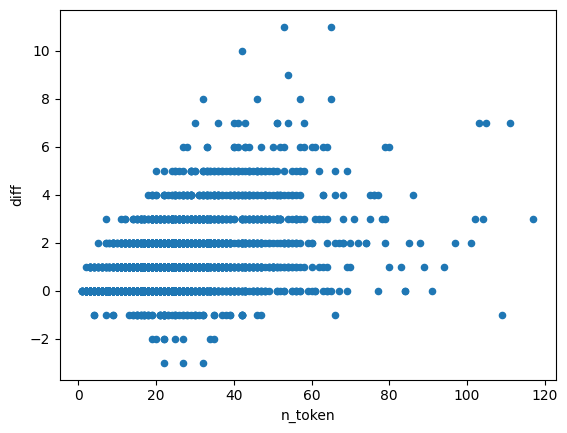

In [547]:
docs = load_docs(fn_train)
metrics = sentence_wise_metrics(docs, 0.05, threshold_len_mult=None, pred_max=18)
metrics.plot(kind="scatter", x="n_token", y="diff");

In [276]:
# precision recall curve

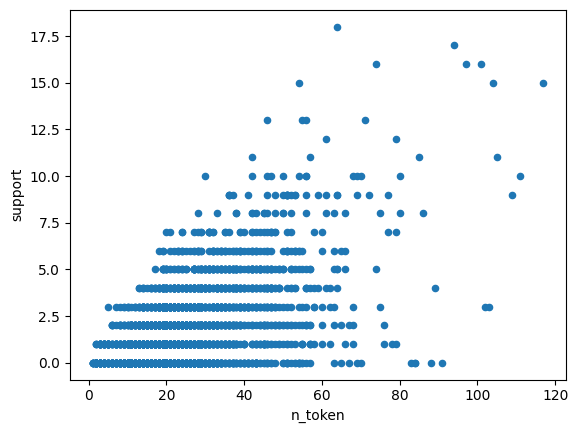

In [311]:
metrics.plot(kind="scatter", x="n_token", y="support");

In [ ]:
metrics

,recall,n_token,n_pred_max,tp,fn,fp,sent_id
0,1.0,30,8,1,0,2,"(00015_1910_09700.txt, 0)"
1,1.0,42,8,0,0,6,"(00015_1910_09700.txt, 1)"
2,1.0,31,10,2,0,3,"(00015_1910_09700.txt, 2)"
3,1.0,31,6,0,0,1,"(00015_1910_09700.txt, 3)"
4,1.0,5,3,0,0,1,"(00015_1910_09700.txt, 4)"
...,...,...,...,...,...,...,...
2952,1.0,23,8,2,0,3,"(10052_2106_02584.txt, 760)"
2953,0.7,80,22,7,3,1,"(10052_2106_02584.txt, 761)"
2954,1.0,25,6,1,0,3,"(10052_2106_02584.txt, 762)"
2955,1.0,33,10,4,0,1,"(10052_2106_02584.txt, 763)"


In [219]:
import json
import random
from itertools import chain

NameError: name 'pd' is not defined

In [206]:
#sent_begin = 0
#for doc in docs:
#    for sent_idx, sentence in enumerate(doc["sentences"]):
#        sent_ner_preds = doc["predicted_ner_proba"][sent_idx]
#        for begin, end, label, proba in sent_ner_preds:
#            if begin >= sent_begin + len(sentence):
#                print("ihh")
#        sent_begin += len(sentence)

In [207]:
import pandas as pd

In [209]:
stats = get_results(docs)

<AxesSubplot:xlabel='n_token', ylabel='n_pred_max'>

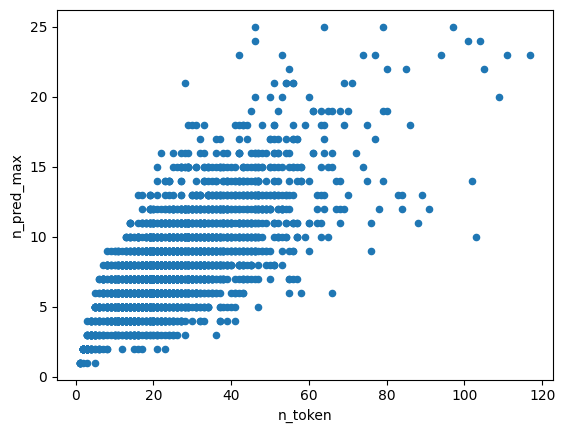

In [163]:
get_results(docs).n_token.describe()

count    2957.000000
mean       25.981062
std        14.406586
min         1.000000
25%        16.000000
50%        23.000000
75%        33.000000
max       117.000000
Name: n_token, dtype: float64

In [ ]:
recall_1_share = (sent_recall.recall == 1.).value_counts().get(True) / len(sent_recall)
recall_all = sent_recall.tp.sum() / (sent_recall.tp.sum() + sent_recall.fn.sum())
precision_all = sent_recall.tp.sum() / (sent_recall.tp.sum() + sent_recall.fp.sum())
predicted_ents = (sent_recall.fp.sum() / sent_recall.tp.sum()  )
recall_all, precision_all, recall_1_share, predicted_ents, sent_recall.fp.sum(), sent_recall.tp.sum()

(0.9256553502363558,
 0.6571079926784624,
 0.6915032679738562,
 0.5218198700092851,
 1124,
 2154)

In [117]:
import numpy as np

In [125]:
bad_recall = sent_recall.recall < 0.5
sent_recall.loc[bad_recall[bad_recall].index]

,sent_idx,recall,tp,fn,fp
65,65,0.333333,1,2,4
86,86,0.000000,0,2,0
221,221,0.000000,0,1,2
228,228,0.000000,0,1,2
249,249,0.428571,3,4,4
314,314,0.000000,0,1,0
391,391,0.000000,0,1,0
406,406,0.333333,1,2,3
412,412,0.000000,0,1,2
415,415,0.000000,0,1,2


In [100]:
sent_infos_fn = [i for i in sent_infos if i["recall"] is not None and i["recall"] <= 1.]
len(sent_infos_fn)

649

In [101]:
tp = len(ner_set & ner_pred_set)
fn = len(ner_set - ner_pred_set)
fp = len(ner_pred_set - ner_set)
recall = tp / len(ner_set)
recall, tp, fn, fp


(1.0, 3, 0, 3)

In [ ]:
sent_info = random.choice(sent_infos_fn)

In [126]:
idx = -1

In [134]:
idx += 1
pos = bad_recall[bad_recall].index[idx]
print(pos)
sent_info = sent_infos_fn[pos]

print(sent_info)
sent_idx = sent_info["sent_idx"]
sentence = doc["sentences"][sent_idx]
ner_pred = doc["predicted_ner_proba"][sent_idx]
ner = doc["ner"][sent_idx]

print(" ".join(sentence))
print("\nner:")
for begin, end, label in ner:
    print(f'[{label}: "{" ".join(doc["doc_tokens"][begin:end+1])}"]')
print("\npredicted ner candidates:")
for begin, end, prob, label in ner_pred:
    print(f'[{label}: "{" ".join(doc["doc_tokens"][begin:end+1])}" ({prob:.2f})]')

249
{'sent_idx': 277, 'recall': 1.0, 'tp': 5, 'fn': 0, 'fp': 5}
NPTs share scaling limitations with all naïvely non - parametric approaches [ 74 ] and GNNs [ 52 ] .

ner:
[ModelArchitecture: "NPTs"]
[MLModelGeneric: "NPTs"]
[MLModelGeneric: "all naïvely non - parametric approaches"]
[ReferenceLink: "74"]
[ModelArchitecture: "GNNs"]
[ReferenceLink: "52"]

predicted ner candidates:
[ReferenceLink: "74" (1.00)]
[ReferenceLink: "52" (1.00)]
[ModelArchitecture: "NPTs" (0.99)]
[ModelArchitecture: "GNNs" (0.99)]
[MLModelGeneric: "all naïvely non - parametric approaches" (0.65)]
[NIL: "naïvely non - parametric approaches" (0.08)]
[NIL: "scaling" (0.04)]
[NIL: "all" (0.01)]
[NIL: "74 ]" (0.00)]
[NIL: "52 ]" (0.00)]


In [57]:
for begin, end, label in ner_pred:
    print(doc["doc_tokens"][begin:end+1], label)

['Instances'] NIL
['few', 'features'] NIL
['learning'] NIL
['accurate', 'feature', 'predictors'] NIL
['feature', 'predictors'] MLModelGeneric
